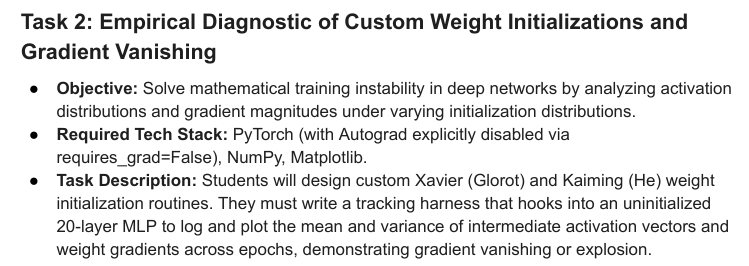

In [1]:
!pip install torch numpy matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)

X = torch.randn(100, 100)

print("Input shape:", X.shape)

Input shape: torch.Size([100, 100])


In [4]:
layers = []

for i in range(20):
    layer = torch.nn.Linear(100, 100)
    layers.append(layer)

print("Number of layers:", len(layers))

Number of layers: 20


In [5]:
def xavier_init(layer):

    if isinstance(layer, torch.nn.Linear):

        fan_in = layer.in_features
        fan_out = layer.out_features

        std = np.sqrt(
            2.0 / (fan_in + fan_out)
        )

        with torch.no_grad():

            layer.weight.normal_(
                mean=0,
                std=std
            )

            layer.bias.zero_()

In [6]:
def kaiming_init(layer):

    if isinstance(layer, torch.nn.Linear):

        fan_in = layer.in_features

        std = np.sqrt(
            2.0 / fan_in
        )

        with torch.no_grad():

            layer.weight.normal_(
                mean=0,
                std=std
            )

            layer.bias.zero_()

In [7]:
def track_activations(layers, X):

    activation_means = []
    activation_variances = []

    x = X

    for layer in layers:

        x = layer(x)

        x = torch.relu(x)

        activation_means.append(
            x.mean().item()
        )

        activation_variances.append(
            x.var().item()
        )

    return activation_means, activation_variances

In [8]:
xavier_layers = []

for i in range(20):

    layer = torch.nn.Linear(100, 100)

    xavier_init(layer)

    xavier_layers.append(layer)

In [9]:
xavier_mean, xavier_variance = track_activations(
    xavier_layers,
    X
)

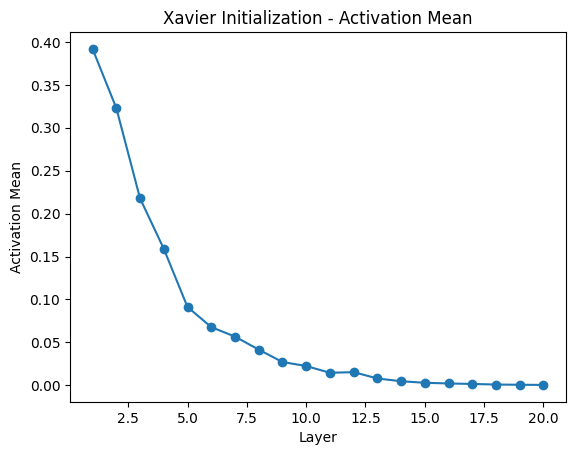

In [10]:
plt.plot(
    range(1, 21),
    xavier_mean,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Activation Mean")

plt.title(
    "Xavier Initialization - Activation Mean"
)

plt.show()

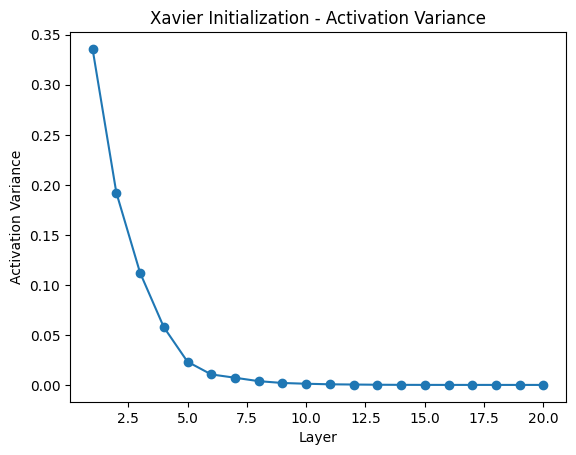

In [11]:
plt.plot(
    range(1, 21),
    xavier_variance,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Activation Variance")

plt.title(
    "Xavier Initialization - Activation Variance"
)

plt.show()

In [12]:
kaiming_layers = []

for i in range(20):

    layer = torch.nn.Linear(100, 100)

    kaiming_init(layer)

    kaiming_layers.append(layer)

In [13]:
kaiming_mean, kaiming_variance = track_activations(
    kaiming_layers,
    X
)

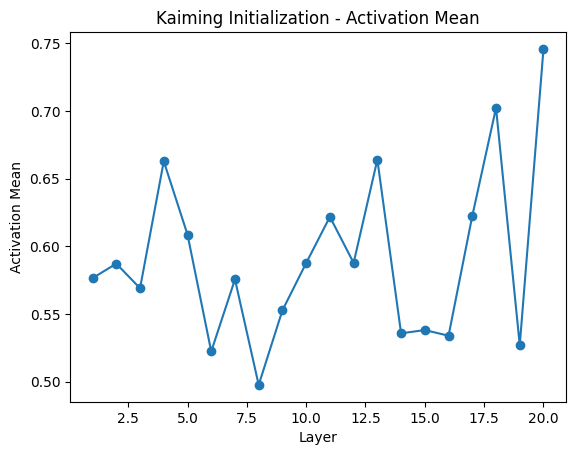

In [14]:
plt.plot(
    range(1, 21),
    kaiming_mean,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Activation Mean")

plt.title(
    "Kaiming Initialization - Activation Mean"
)

plt.show()

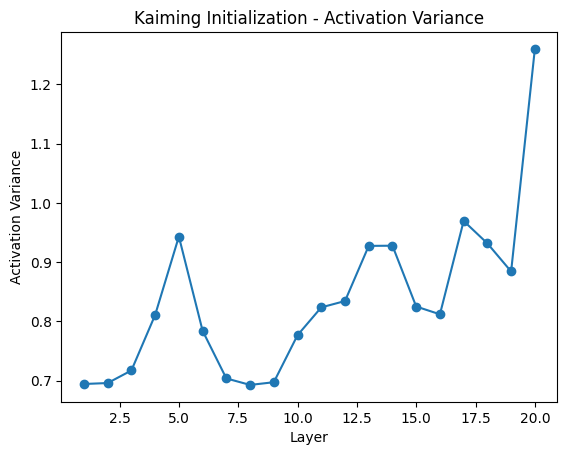

In [15]:
plt.plot(
    range(1, 21),
    kaiming_variance,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Activation Variance")

plt.title(
    "Kaiming Initialization - Activation Variance"
)

plt.show()

In [16]:
Y = torch.randn(100, 100)

In [17]:
def track_gradients(layers, X, Y):

    x = X

    activations = []

    for layer in layers:

        x = layer(x)

        x = torch.relu(x)

        activations.append(x)

    loss = torch.mean(
        (x - Y) ** 2
    )

    loss.backward()

    gradients = []

    for layer in layers:

        gradient = layer.weight.grad.abs().mean().item()

        gradients.append(gradient)

    return gradients, loss.item()

In [18]:
xavier_gradients, xavier_loss = track_gradients(
    xavier_layers,
    X,
    Y
)

print("Xavier Loss:", xavier_loss)

Xavier Loss: 0.9912718534469604


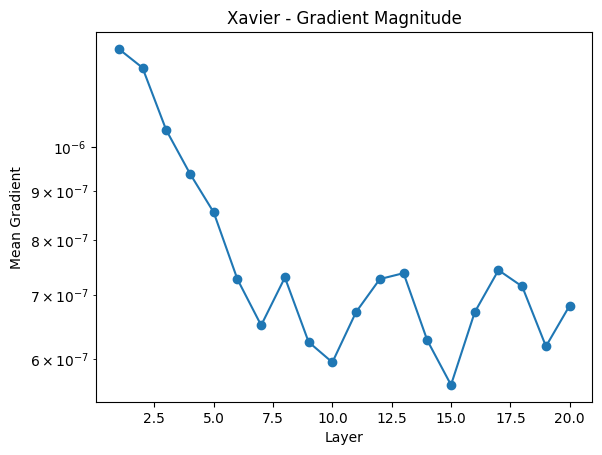

In [19]:
plt.plot(
    range(1, 21),
    xavier_gradients,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Mean Gradient")

plt.title(
    "Xavier - Gradient Magnitude"
)

plt.yscale("log")

plt.show()

In [20]:
kaiming_layers = []

for i in range(20):

    layer = torch.nn.Linear(100, 100)

    kaiming_init(layer)

    kaiming_layers.append(layer)

In [21]:
kaiming_gradients, kaiming_loss = track_gradients(
    kaiming_layers,
    X,
    Y
)

print("Kaiming Loss:", kaiming_loss)

Kaiming Loss: 1.3164482116699219


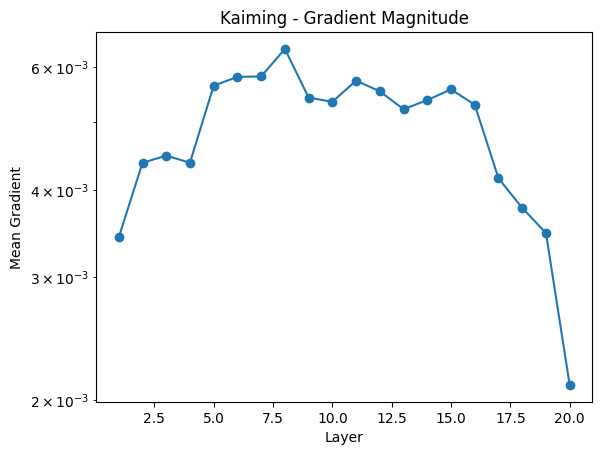

In [22]:
plt.plot(
    range(1, 21),
    kaiming_gradients,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Mean Gradient")

plt.title(
    "Kaiming - Gradient Magnitude"
)

plt.yscale("log")

plt.show()

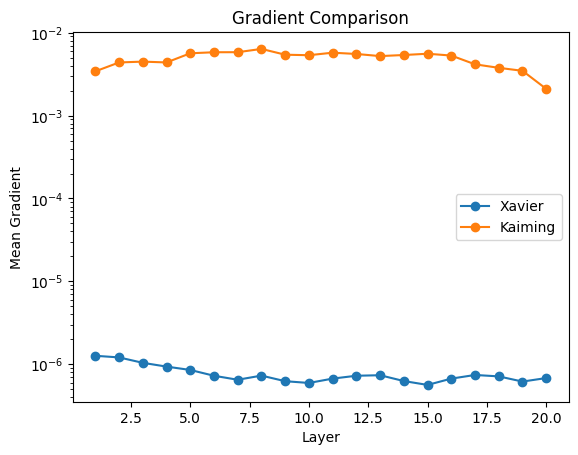

In [23]:
plt.plot(
    range(1, 21),
    xavier_gradients,
    marker="o",
    label="Xavier"
)

plt.plot(
    range(1, 21),
    kaiming_gradients,
    marker="o",
    label="Kaiming"
)

plt.xlabel("Layer")
plt.ylabel("Mean Gradient")

plt.title(
    "Gradient Comparison"
)

plt.yscale("log")

plt.legend()

plt.show()

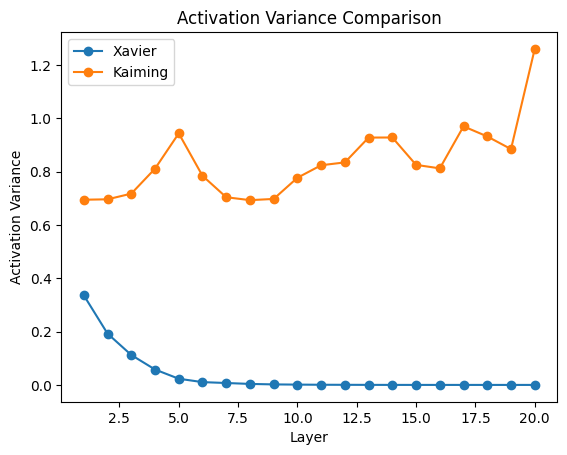

In [24]:
plt.plot(
    range(1, 21),
    xavier_variance,
    marker="o",
    label="Xavier"
)

plt.plot(
    range(1, 21),
    kaiming_variance,
    marker="o",
    label="Kaiming"
)

plt.xlabel("Layer")
plt.ylabel("Activation Variance")

plt.title(
    "Activation Variance Comparison"
)

plt.legend()

plt.show()

In [25]:
print("Layer | Xavier Var | Kaiming Var")
print("-" * 35)

for i in range(20):

    print(
        f"{i+1:5d} | "
        f"{xavier_variance[i]:10.6f} | "
        f"{kaiming_variance[i]:10.6f}"
    )

Layer | Xavier Var | Kaiming Var
-----------------------------------
    1 |   0.335851 |   0.694332
    2 |   0.192325 |   0.695916
    3 |   0.112214 |   0.717167
    4 |   0.057802 |   0.810823
    5 |   0.023182 |   0.943122
    6 |   0.010506 |   0.784113
    7 |   0.007193 |   0.703718
    8 |   0.003760 |   0.692754
    9 |   0.001942 |   0.697297
   10 |   0.001183 |   0.776699
   11 |   0.000620 |   0.823621
   12 |   0.000398 |   0.834299
   13 |   0.000187 |   0.927380
   14 |   0.000070 |   0.927679
   15 |   0.000027 |   0.825029
   16 |   0.000012 |   0.811927
   17 |   0.000005 |   0.969434
   18 |   0.000002 |   0.931578
   19 |   0.000001 |   0.884188
   20 |   0.000000 |   1.259750
